In [ ]:
pip install requirements.txt

HINT: You are attempting to install a package literally named "requirements.txt" (which cannot exist). Consider using the '-r' flag to install the packages listed in requirements.txt
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement requirements.txt (from versions: none)
ERROR: No matching distribution found for requirements.txt


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [7]:
df = pd.read_csv('data/canada_per_capita_income.csv')

In [8]:
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [9]:
print(LinearRegression)


<class 'sklearn.linear_model._base.LinearRegression'>


In [10]:
reg = LinearRegression()
reg.fit(df[['year']],df['per capita income (US$)'])
reg.predict([[2020]])

c:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41288.69409442])

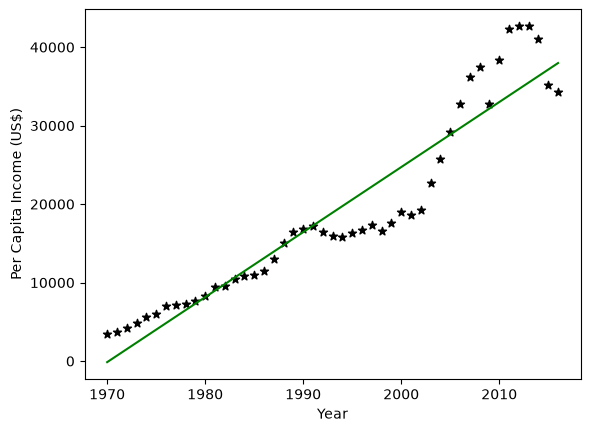

In [11]:
%matplotlib inline
plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.scatter(df[['year']],df['per capita income (US$)'],color ='black', marker='*')
plt.plot(df[['year']],reg.predict(df[['year']]),color='green')


In [18]:
future = pd.DataFrame({'year': [year for year in range(2017, 2027)]})
future['predicted_income'] = reg.predict(future)

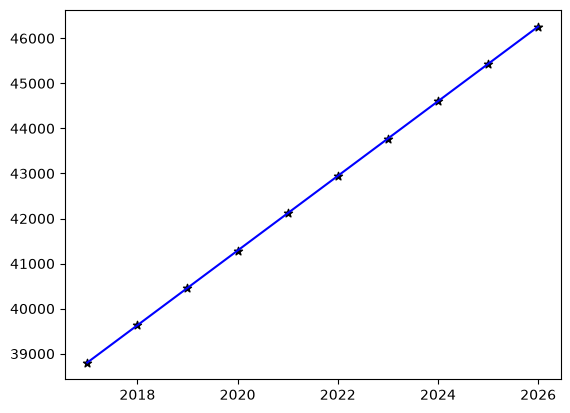

In [25]:
plt.plot(future['year'],future['predicted_income'],color ='blue')
plt.scatter(future['year'],future['predicted_income'],color ='black', marker='*')

In [26]:
future.to_csv('predicted_income.csv', index=False)

In [30]:
X = df[['year']]
y= df['per capita income (US$)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[815.14]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.606e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [31]:
y_pred = reg.predict(X_test)

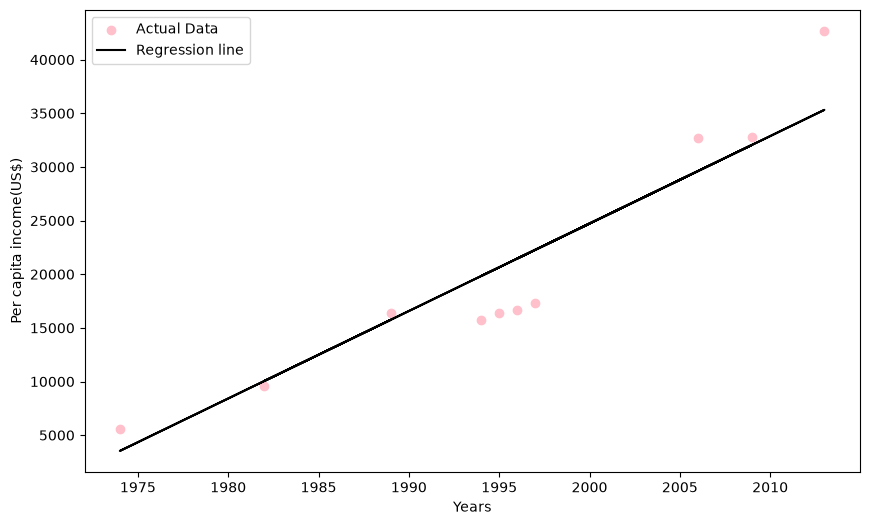

In [35]:
plt.figure(figsize =(10,6))
plt.scatter(X_test, y_test, color='pink', marker='o', label='Actual Data')
plt.plot(X_test, y_pred, color='black', label='Regression line')
plt.xlabel("Years")
plt.ylabel("Per capita income(US$)")
plt.legend()
plt.show()

In [36]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")

R² Score : 0.8752
MAE      : 3240.91
MSE      : 15147815.55
RMSE     : 3892.02


In [37]:
results = X_test.copy()
results['Actual value'] = y_test
results['Predicted value'] = y_pred
results

,year,Actual value,Predicted value
27,1997,17310.757750,22279.399682
39,2009,32755.176820,32061.109839
26,1996,16699.826680,21464.257169
43,2013,42676.468370,35321.679891
24,1994,15755.820270,19833.972143
36,2006,32738.262900,29615.682300
12,1982,9619.438377,10052.261987
19,1989,16426.725480,15758.259578
4,1974,5576.514583,3531.121883
25,1995,16369.317250,20649.114656


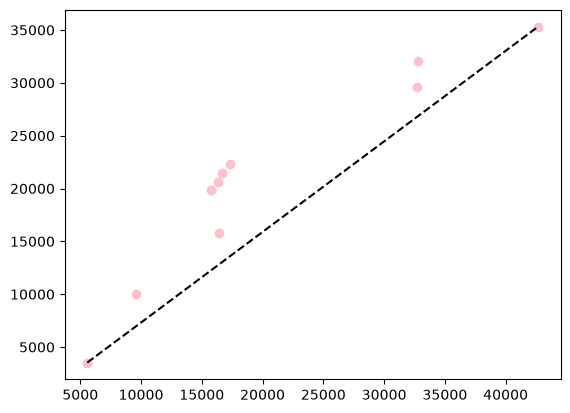

In [39]:
plt.scatter(results['Actual value'], results['Predicted value'], color='pink')
plt.plot([results['Actual value'].min(), results['Actual value'].max()],[results['Predicted value'].min(),results['Predicted value'].max()], color= 'black', linestyle="--")